# <div>
# <img src="https://i.imgur.com/rqmo4C0.png" width=200/>
# </div>

# Lesson 10 - LLMs, Prompt Engineering & Agents

By the end of this notebook, you should be able to answer the following questions:

- What are <b>LLMs</b>? What are the main providers? How can you interact with these models?

- What is <b>Prompt Engineering</b>, and why does it matter? What are some useful <b>techniques</b>?

- What are <b>agents</b>? What can they do? What are some of the most important <b>agent frameworks</b>?

## 0. Prerequisites & Setup

- Make sure you have created a clean Python environment & you are currently inside it.
- Make sure your Python version is 3.8 or above.

In [ ]:
# OpenAI & tokenizer
!pip install openai tiktoken

# Agent packages & tools
!pip install langchain langchain-experimental langchain-openai langgraph smolagents tavily-python loguru duckduckgo-search

# RAG packages & tools
!pip install lancedb sentence-transformers tantivy beautifulsoup4 ragas

In [ ]:
import tiktoken
import json
import os

from typing import TypedDict, List
from getpass import getpass

from openai import OpenAI

from pydantic import BaseModel, Field
from tavily import TavilyClient
from loguru import logger

from langchain.prompts import SystemMessagePromptTemplate, HumanMessagePromptTemplate, MessagesPlaceholder
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
from langchain.tools import tool as langchain_tool

from langgraph.graph import StateGraph, END

from smolagents import CodeAgent, OpenAIServerModel
from smolagents import tool as smolagents_tool

In [ ]:
if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

OPENAI_MODEL = "gpt-4o"
OPENAI_MODEL_SMALL = "gpt-4o-mini"
OPENAI_MODEL_LEGACY = "gpt-3.5-turbo"
OPENAI_CLIENT = OpenAI() # Reads the API key from the environment variable

# Tavily - Web Search API
# Get API key from https://tavily.com/

if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key: ")

TAVILY_CLIENT = TavilyClient()

## 1. Introduction to LLMs

### 1.0. A Brief History

<div style="width: 80%; text-align: justify">

- Even since the 1950s, <b>early probabilistic methods like [Markov chains](https://benhoyt.com/writings/markov-chain/)</b> could generate text by treating strings as fixed-order sequences. Thus, given a starting word, the next one would be predicted via maximum likelihood from a learned corpus. In the first column below, you can see an example of a Markov chain trained on Edgar Allan Poe's work. While the resulting text is legible, it's semantically worthless - only the current word is used for generating the next one, and long-range dependencies are not captured.

- The next logical step, Natural Language Processing (NLP), took off dramatically in the 2010s. One of the most important contributions from this period is the <b>Recurrent Neural Network</b>, which uses an internal state (memory) for modeling sequential dependencies from previous inputs - however, it suffered from the vanishing gradient problem, namely the diminishing of gradients as they were backpropagated through time, leading to very slow training or information loss. An extension of RNNs, Long Short-Term Memory (LSTM), has been developed in order to solve vanishing gradients by leveraging gating mechanisms that control the flow of information and gradients, thus leading to better learning and information retainment over longer sequences. However, training these models was still slow, and they still struggled over texts exceeding ~200 tokens. A text sample from an RNN trained on Shakespeare's work can be seen in the second column.

- The Transformer revolution, which started with the 2017 "Attention is All You Need" paper, quickly replaced recurrence with <b>multi-head self-attention and feed-forward layers</b>. Attention models, compared to RNNs, were much better at capturing long-range context, as global attention could connect any token pair directly, and much more scalable, as they could be trained more efficiently on massive text corpora. Virtually all of today's commercial LLM (large language model) families, such as GPT, Gemini, Claude, Llama and so on, use a Transformer backbone - however, as we'll see in the following section, some of them make use of certain modifications for optimizations such as higher performance or faster generation.

- Today's models support multiple tools (search, deep research, reasoning) and can be used for generating stories, code, lyrics, ASCII art, and virtually anything that is made of text. As a throwback to the <b>[Electronic Bard](https://electricliterature.com/wp-content/uploads/2017/11/Trurls-Electronic-Bard.pdf)</b>, Stanislaw Lem's prediction of ChatGPT from precisely 60 years ago, the third column showcases GPT 4.5's impressive attempt at creating a poem with complex constraints - six lines, each word starting with the letter 's'.

- The next steps are, as of writing this notebook, unclear - although [some voices](https://www.newsweek.com/ai-impact-interview-yann-lecun-llm-limitations-analysis-2054255) claimed that we're bound to hit a wall with LLMs, as returns seem to be diminishing, breakthroughs such as <b>[Alpha Evolve](https://deepmind.google/discover/blog/alphaevolve-a-gemini-powered-coding-agent-for-designing-advanced-algorithms/)</b>, which has already enhanced the efficiency of Google's data centers and discovered a matrix multiplication algorithm that breaks decades-old records, seem to indicate otherwise.

</div>

<table>
    <tr>
        <td>
            <img src="https://i.imgur.com/BirLwcy.png" width="400px">
        </td>
        <td>
            <img src="https://i.imgur.com/ADgvA4p.png" width="400px">
        </td>
        <td>
            <img src="https://i.imgur.com/B5VhKum.png" width="450px">
        </td>
    </tr>
</table>

### 1.1. Today's LLM Landscape

<div style="width: 80%; text-align: justify">

In order to understand the LLM world, it's useful to get an overview of its main flavours. We'll start with a brief recap of the Transformers architecture, after which we'll explore the different categories of LLMs and their defining characteristics.

</div>

#### 1.1.1. Transformer Architecture - Recap

<img src="https://i.imgur.com/1tBAjsC.png" style="height:500px"/>

<div style="width: 80%; text-align: justify">

<b>Step 1: Input Embeddings & Positional Encoding</b>

Each word from the input sentence is converted into a fixed-size embedding vector (e.g., 512 dimensions). Positional embeddings are then added to these word embeddings, providing information about each token’s position in the sequence, since transformers don't inherently account for token order.

<b>Step 2: Encoder (Contextualizing Tokens)</b>

The embedded tokens enter the encoder, which consists of multiple identical blocks, each containing:

- <b>Multi-head Self-Attention</b>: Captures relationships between words by allowing each word to "attend" to all positions simultaneously, thus embedding context into every token.

- <b>Feed-forward Network (FFN)</b>: Further transforms these representations.

- <b>Normalization Layers</b>: Ensures stable learning through normalization.

The output of the final encoder block is a set of context-rich vectors representing the meaning of the entire input sequence.

<b>Step 3: Decoder (Generating Output)</b>

The decoder generates output tokens autoregressively, meaning it uses previously generated tokens to predict the next one. Each decoder block includes:

- <b>Masked Multi-head Self-Attention</b>: Prevents positions from attending to future tokens, ensuring predictions rely only on known or previously generated tokens.

- <b>Encoder-Decoder Attention</b>: Integrates context from the encoder’s output, allowing the decoder to condition generation on the input.

- <b>Feed-forward Network & Normalization Layers</b>: Similar transformations and stabilization as in the encoder.

<b>Step 4: Output Generation</b>

The decoder's final vector is projected through a linear layer to produce logits (raw scores) for each vocabulary token. A softmax function then converts these logits into a probability distribution, from which the next token is selected (sampled) as the model's prediction.

</div>

#### 1.1.2. How do LLMs differ from vanilla Transformers?

<div style="width: 80%; text-align: justify">

- While the vanilla Transformer includes <b>both encoder and decoder blocks</b>, an ideal setup for translation and other seq2seq (sequence-to-sequence) tasks, LLMs usually adopt <b>decoder-only architectures</b> (e.g. GPT), since encoders are not needed for the text-generation task. This greatly simplifies training and inference, allowing LLMs to scale massively.

- While vanilla Transformers are trained on <b>relatively small, task-specific datasets</b>, and their parameter count is in the range of <b>millions of parameters</b>, LLMs are trained on <b>extremely vast, heterogeneous corpora (web data, books, etc.)</b> and reach <b>parameter counts in the trillions</b> (e.g. GPT-4 has 1.76T parameters).

- Vanilla Transformers are primarly trained with <b>supervised learning (task-specific labeled data)</b>, and are focused on optimizing a particular performance metric for a single task. On the other hand, LLMs are trained via <b>autoregressive next-token prediction or self-supervised pretraining</b>. Moreover, LLMs can also be better aligned to human values via useful techniques such as <b>Reinforcement Learning from Human Feedback (RLHF)</b>.

</div>

#### 1.1.3. LLM Sampling Parameters - temperature, top-p, top-k

<div style="width: 80%; text-align: justify">

When LLMs generate text, they don't simply pick the most probable next token. Instead, they use various **sampling parameters** to control the randomness and quality of the generated output. These parameters allow us to fine-tune the balance between creativity and coherence in the model's responses.

- **Temperature (τ)**
  - Controls the randomness of token selection by scaling the logits before applying softmax
    - <b>Temperature = 0</b>: Greedy decoding - always selects the most probable token
    - <b>Temperature < 1</b>: More focused, conservative outputs
    - <b>Temperature = 1</b>: Standard probability distribution
    - <b>Temperature > 1</b>: More creative, diverse, but potentially less coherent outputs

The diagram below visually demonstrates how different temperature settings affect the probability distribution of the next token, with higher temperatures leading to a flatter distribution (more randomness) and lower temperatures leading to a spikier distribution (more determinism).

<br/>
<img src="https://i.imgur.com/YXIEYEi.png" width="450px">

- **Top-k Sampling**
  - Restricts the model to only consider the k most probable tokens at each step
    - <b>k = 1</b>: Equivalent to greedy decoding
    - <b>k = 10-50</b>: Common range for balanced creativity and coherence
    - <b>Higher k</b>: More diverse but potentially less focused outputs

- **Top-p (Nucleus) Sampling**
  - Dynamically selects from the smallest set of tokens whose cumulative probability exceeds a threshold p
    - <b>p = 0.1</b>: Very conservative, only high-confidence tokens
    - <b>p = 0.7-0.9</b>: Common range for most applications
    - <b>p = 1.0</b>: Considers all tokens (equivalent to standard sampling)

The subsequent diagram illustrates the difference between top-k and top-p sampling. Top-k selects a fixed number of the most probable tokens, while top-p selects a variable number of tokens whose cumulative probability exceeds the threshold p.

<br/>
<img src="https://i.imgur.com/NGTUvst.png" width="450px">

These parameters are often used in combination to achieve the desired balance between creativity, coherence, and diversity in LLM outputs.

</div>

#### 1.1.4. What are the main LLM families out there today?

##### a. GPT Family (OpenAI)

<div style="width: 80%; text-align: justify">

<b>Generative Pre-trained Transformers (GPT)</b> are a family of <b>proprietary, decoder-only Transformer-based language models</b> developed by OpenAI.

While <b>earlier models (GPT-1, GPT-2) are transparent in regards to their architectures, parameter counts, training data, and used hardware</b>, this is not the case with newer models, especially since the release of GPT-4, due to concerns over competitive advantages and safety implications. There are, however, <b>[rumors that GPT-4 uses a Mixture of Experts architecture, with a total of 1.76 trillion parameters](https://x.com/soumithchintala/status/1671267150101721090?ref_src=twsrc%5Etfw%7Ctwcamp%5Etweetembed%7Ctwterm%5E1671267150101721090%7Ctwgr%5E89a9c30d751c1fc05105bf25b60ec5101aaae32c%7Ctwcon%5Es1_&ref_url=https%3A%2F%2Fwww.redditmedia.com%2Fmediaembed%2F14eowmw%2F%3Fresponsive%3Dtrueis_nightmode%3Dtrue)</b>.

However, the diagram below, a conceptual overview of the GPT architecture, reflects how this type of LLM deviates from the Vanilla Transformers architecture, opting for a decoder-only variant.

<img src="https://i.imgur.com/1Z8RuXm.png">

The GPT family consists of models such as:

- <b>[ChatGPT](https://openai.com/index/chatgpt/)</b> (November 2022): a language model that sparked the LLM phenomenon. This model was stated as being a fine-tuned version based on the GPT-3.5 series, using Reinforcement Learning from Human Feedback (RLHF), a technique previously used for aligning InstructGPT, a small model developed in January 2022.
- <b>GPT-4 family</b> - The latest iteration as of June 2025
    - <b>[GPT-4 Base Model](https://openai.com/index/gpt-4/)</b> (March 2023): OpenAI's fourth-generation large language model introduced significant improvements in reasoning and general knowledge over GPT-3.5. It was trained to predict the next token in a sequence, primarily handling text inputs and outputs.

    - <b>[GPT-4 Vision](https://openai.com/index/gpt-4v-system-card/)</b> (November 2023): An extension of GPT-4 that incorporated vision capabilities, allowing the model to process and understand images alongside text. This enhancement enabled applications such as image captioning and visual question answering.

    - <b>[GPT-4o](https://openai.com/index/hello-gpt-4o/)</b> (May 2024) and 4o-mini (July 2024): "GPT-4o" stands for "omni," reflecting its ability to process and generate text, images, and audio. Moreover, 4o-mini offered faster inference at a slightly weaker performance.

    - <b>[GPT-4.5](https://openai.com/index/introducing-gpt-4-5/)</b> (February 2025): Codenamed "Orion," GPT-4.5 is OpenAI's largest model for chat as of date. Users suggest that while it's not the best at tasks that require complex reasoning, it has a greater EQ, and it feels more natural.

    - <b>[GPT-4.1, GPT-4.1 mini and GPT-4.1 nano](https://openai.com/index/gpt-4-1/)</b> (April 2025): This iteration brought a massive 1 million token context window and improved coding capabilities, outperforming previous models in tasks like code diffs across various programming languages. It also demonstrated superior instruction-following abilities.

    - <b>[GPT-5](https://openai.com/index/introducing-gpt-5/)</b> (August 2025): Better reasoning, fewer hallucination rates; replaced previous iterations, with frontier model access even for Free users;


- <b>o-family</b> - The family of reasoning models:
    - <b>[o1 (Q*) and o1-mini](https://openai.com/o1/)</b> (September 2024): The o1 series marked OpenAI's foray into models designed for enhanced reasoning. These models were trained to spend more time thinking before responding, enabling them to tackle complex tasks in science, coding, and math. The o1-mini variant offered similar capabilities with faster inference and reduced computational demands.

    - <b>[o3 (April 2025) and o3-mini](https://openai.com/index/introducing-o3-and-o4-mini/)</b> (January 2025): Building upon the o1 series, the o3 models introduced the ability to set the level of reasoning effort: low, medium, and high. Moreover, it outperforms o1 significantly on complex tasks.
    
    - <b>[o4-mini](https://openai.com/index/introducing-o3-and-o4-mini/)</b> (April 2025): The o4-mini model further advanced OpenAI's reasoning capabilities, supporting both text and image inputs. Moreover, it outperforms reasoning predecessors and allows performing tasks like analyzing whiteboard sketches during its "chains-of-thought" phase.

</div>

##### b. Gemini Family (Google)

<div style="width: 80%; text-align: justify">

Gemini is a suite of <b>advanced, multimodal AI models</b> developed by <b>Google DeepMind</b>. Designed to process and generate text, code, images, audio, and video, Gemini models are integrated across Google's ecosystem, including Search, Workspace, Android, and Chrome.

While the first generation of Gemini models (Gemini 1) was comprised of decoder-only transformers, starting from
Gemini 1.5 onward, this family of models opted for a Sparse Mixture of Experts architecture. Moreover, these models contain tailored modifications for better training and inference on TPUs, Google's proprietary hardware.

</div>

<div style="width: 80%; text-align: justify; background-color:rgb(219, 250, 254); padding: 15px; border-left: 5px solid #ccc;">

<b>What is a Mixture of Experts?</b>

The Mixture-of-Experts (MoE) architecture is an advanced neural network design that enhances the efficiency and scalability of large language models (LLMs). Unlike traditional dense models that activate all parameters for every input, MoE models dynamically select a subset of specialized sub-networks, known as "experts," to process each input.

<b>🔍 Core Components of MoE</b>:
- <b>Experts</b>: These are specialized sub-networks within the model, each trained to handle specific patterns or types of data. For instance, one expert might specialize in numerical reasoning, while another focuses on language translation.

- <b>Gating Network</b>: This component determines which experts are most suitable for a given input. It routes the input to the selected experts based on learned criteria, ensuring that only relevant experts are activated.

- <b>Sparse Activation</b>: In MoE models, only a small fraction of the total experts are activated for each input. This approach reduces computational load and allows the model to scale effectively without a proportional increase in resource requirements.

<img src="https://i.imgur.com/yF4dwBc.png" width="450px" style="display:inline-block; vertical-align:top; margin-bottom: 15px;">
<img src="https://i.imgur.com/RZJEqML.png" width="450px" style="display:inline-block; vertical-align:top;">

</div>

<div style="width: 80%; text-align: justify">

The Gemini family comprises the following models:
- <b>[1.0 Nano, 1.0 Pro](https://blog.google/technology/ai/google-gemini-ai/)</b> (December 2023), and <b>[1.0 Ultra](https://blog.google/technology/ai/google-gemini-ai/)</b> (February 2024): decoder-only Transformer models, with vision capabilities. 1.0 Pro presented comparable performance to the SOTA at the time (e.g. GPT-4V), while 1.0 Ultra outperformed it on virtually all benchmarks; meanwhile, 1.0 Nano was a [distilled]https://snorkel.ai/blog/llm-distillation-demystified-a-complete-guide/) version of a larger Gemini model, optimized for mobile devices. All 1.0 models are discontinued as of 2025.

- <b>[1.5 Pro](https://blog.google/technology/ai/google-gemini-next-generation-model-february-2024/)</b> (February 2024) and <b>[1.5 Flash](https://blog.google/technology/ai/google-gemini-next-generation-model-february-2024/)</b> (May 2024): Multi-modal sparse MoE models that became famous for their long context windows (reaching 10 million tokens in experiments and 1 million tokens in production, the first model ever to handle this among large-scale models) and their impressive Needle in A Haystack performance (finding small pieces of information in extremely large blocks of text); moreover, 1.5 Flash was a distilled version of 1.5 Pro, optimized for faster inference. As of 2025, these models are discontinued

- <b>[2.0 Flash and 2.0 Pro](https://blog.google/technology/google-deepmind/google-gemini-ai-update-december-2024/)</b> (February 2025): Gemini 2.0 Flash, the first model from this family, outperformed even 1.5 Pro on key benchmarks, at twice the speed. Moreover, it supported new capabilities, such as multimodal output (generating images and text at the same time), and native tool calling (e.g. Google Search). 2.0 Pro raised the bar again, outperforming the SOTA at the time in multiple key tasks such as coding.

- <b>[2.5 Pro](https://blog.google/technology/google-deepmind/gemini-model-thinking-updates-march-2025/)</b> (March 2025) and <b>[2.5 Flash](https://blog.google/technology/google-deepmind/gemini-model-thinking-updates-march-2025/)</b> (April 2025): Gemini 2.5 Pro is a thinking model, and is currently the de-facto leader across a range of key benchmarks by a significant margin. Moreover, 2.5 Flash is the newest model, outperforming models such as Claude 3.7 Sonnet on numerous benchmarks at a fraction of a cost.

</div>

##### c. Claude Family (Anthropic)

<div style="width: 80%; text-align: justify">

Claude is a family of large language models (LLMs) developed by Anthropic, an AI safety and research company founded by former OpenAI researchers. Named after Claude Shannon, the father of information theory, While Anthropic has not publicly disclosed specific architectural details such as parameter counts or the exact number of layers, available information indicates that the Claude models, including Claude 3 and its successors, utilize the decoder-only Transformer framework.

Claude models are designed with a focus on transparency, helpfulness, and harmlessness. They employ a unique training methodology called <b>Constitutional AI</b>, which guides the models to adhere to a set of ethical principles during interactions, reducing reliance on human feedback for alignment. It involves two phases:
1. <b>Supervised learning</b>, where the model critiques and revises its responses based on a set of guiding principles (a "constitution")
2. <b>Reinforcement learning from AI feedback (RLAIF)</b>, where the model is fine-tuned to align with these principles.


<img src="https://i.imgur.com/8k1nQ0i.png" width="450px">

As of June 2025, the Claude family comprises the following models:

- <b>[Claude v1 and Claude Instant](https://www.anthropic.com/news/introducing-claude)</b> (March 2023): The first generation on models, while not outperforming its contenders at the time, was remarked due to its emphasis on safety, honesty and harmlessness. It boasted a significant context window of up to 100,000 tokens. Claude Instant was the faster, more cost-effective version. These models, as of 2025, are retired.

- <b>[Claude 2](https://www.anthropic.com/news/claude-2)</b> (July 2023) and <b>[Claude 2.1](https://www.anthropic.com/news/claude-2-1)</b> (November 2023): This updated delivered a substantial leap forward, narrowing the gap between it and other contemporary models. Moreover, a crucial enhancement was a significant reduction in the rate of "hallucinations", or factually incorrect statements, making it a more reliable tool.

- <b>[Claude 3 Haiku, Sonnet and Opus](https://www.anthropic.com/news/claude-3-family)</b> (March 2024): A pivotal moment in the evolution of the Claude family introduced a trio of distinct systems, each designed for different needs. While Haiku is optimized for near-instantaneous responses to simple queries, Opus was larger, designed to handle highly complex tasks, and Sonnet striked a balance between the two. Moreover, vision capabilities were introduced.

- <b>[Claude 3.5 Haiku](https://www.anthropic.com/claude/haiku)</b> (October 2024) and <b>[Sonnet](https://www.anthropic.com/news/claude-3-5-sonnet)</b> (June 2024): These two models outperformed their predecessors at comparable inference speeds (3.5 Sonnet outperformed 3.0 Opus). Moreover, key features introduced were Artifacts (real-time code previews) and groundbreaking experimental computer use functionality for automating workflows.

- <b>[Claude 3.7 Sonnet](https://www.anthropic.com/news/claude-3-7-sonnet)</b> (February 2025): This model introduced "hybrid reasoning" with Extended Thinking, and Claude Code, an agentic coding tool that can search and read code, edit files, write and run tests, and so forth. However, the Claude model continued to lag behind in native multimodal capabilities beyond text and images.

- <b>[Claude 4 Sonnet and Opus](https://www.anthropic.com/news/claude-4)</b> (May 2025): These models are positioned as leading forces in complex, multi-step coding and agent-based workflows, directly surpassing even Gemini 2.5 Pro in these specific domains. However, it lags behind in other domains, such as general reasoning or creative writing.

</div>

##### d. LLaMA Family (Meta)

<div style="width: 80%; text-align: justify">

Large Language Model Meta AI (LLaMA) is a family of LLMs released by Meta AI. LLaMA stands out due to its commitment to open-weight access, as starting with the second iteration, the model weights were made accessible outside academia and released under licenses that even permitted some commercial use.

LLaMA models 1-3 are built on the decoder-only transformer architecture, while LLaMA 4 opted for a Mixture-of-Experts architecture (discussed previously in the Gemini case). However, the LLaMA models introduce some minor differences:
- While other LLMs typically use activation functions like ReLU or GELU in their FFN layers, LLaMA models opted to replace them with <b>SwiGLU</b>. It combines aspects of the Swish activation function and Gated Linear Units (GLUs), and it has been empirically shown to improve performance in tasks such as language modeling, leading to better convergence during training.

<img src="https://i.imgur.com/qVCnS7r.jpeg" width="450px">
<img src="https://i.imgur.com/xZIUp5B.png" width="450px">

- Instead of using absolute positional embeddings, LLaMA models use <b>Rotary Positional Embeddings (RoPE)</b>. Namely, instead of adding positional embeddings to the token embedding, RoPE rotates the token embedding based on its position. Since embeddings are high-dimensional vectors, a series of 2D rotations iss applied to pairs of dimensions. For a token at position <i>m</i>, each 2D rotation is applied at an angle proportional to <i>m</i>. This approach is better for encoding relative positional information, meaning that the model understands how far apart two tokens are, and not just their absolute positions.

- LLaMA models, starting with LLaMA 2, use <b>Grouped-Query Attention (GQA)</b>, an approach that reduces memory requirements during inference by grouping query heads. While in other Transformers architecture, each attention head has its own key and value projections (Multi-Head Attention, or MHA), GQA groups several query heads together so they share key/value projections.

- One of the latest models, LLaMA 4 Scout, uses a technique called <b>Interleaved Positional Embeddings (iRoPE)</b>, which implies alternating layers that use RoPE with layers that don't have any explicit positional encoding (called NoPE) but rely on other tricks, like modified softmax temperatures, to track token order. This approach saves compute and appears to help with extremely long context windows (up to 10 million tokens).

The LLaMA family comprises the following LLMs:
- <b>[LLaMA 1](https://ai.meta.com/blog/large-language-model-llama-meta-ai/) - 7B, 33B and 65B</b> (February 2023): The original research models, demonstrating that smaller models could match larger contemporary proprietary models, such as GPT-3, on many tasks. The model was only released under a noncommercial license focused on research use cases, with access granted on a case-by-case basis.

- <b>[LLaMA 2](https://www.llama.com/llama2/) - 7B, 13B and 70B</b> (July 2023): A significant move toward open AI, with free research and commercial use, with certain restrictions. These models were trained on more data than LLaMA 1 models, displaying higher performance. Moreover, this is when fine-tuned versions, optimized for conversations via RLHF, were released.

- <b>[LLaMA 3](https://ai.meta.com/blog/meta-llama-3/) - 8B and 70B</b> (April 2024): Models with state-of-the-art performance in their respective size categories. Moreover, new cybersecurity evaluation benchmarks and guardrails were introduced, as Meta emphasised on trust and safety (Llama Guard, Cybersec Eval, and Code Shield).

- <b>[LLaMA 3.1](https://ai.meta.com/blog/meta-llama-3-1/) - 405B</b> (July 2024): The largest open-access LLM at the time. It achieved parity with top proprietary models like GPT-4 or Claude 3.5 on tasks like general knowledge, math, and tool-use. It was also trained on an impressive amount of tokens (15 trillion).

- <b>[LLaMA 4](https://ai.meta.com/blog/llama-4-multimodal-intelligence/) - Scout 109B and Maverick 400B</b> (April 2025): MoE experts, with 16 experts for Scout (17B active parameters) and 128 experts for Maverick (17B active parameters). Also, Scout supports an industry-leading context window length of 10 million tokens. Both models are strong contenders in their size classes, surpassing models like Gemini 2.0 Flash on certain benchmarks.

</div>

### 1.2. Small Demo - Calling an LLM's API

<div style="width: 80%; text-align: justify">

By now, I'm sure that you've had the occasion to use LLMs, such as ChatGPT or Gemini, directly via their UIs. A straightforward example is heading to <b>[ChatGPT](https://chatgpt.com)</b>, selecting a model from the dropdown menu, and starting a chat. However, integrating LLMs into application requires getting familiar with LLM APIs.

Virtually every provider (e.g. OpenAI, Anthropic) provides an API platform where users can view model details & pricing tables, create API keys, and start developing. In this section, we'll look at OpenAI's API, go over the parameters that users can specify, and test out a few calls. In the following sections, we'll build from the bottom-up, starting with some prompt engineering using OpenAI's API, and then looking at some frameworks that abstract away these low-level APIs and allow us to focus on more complex workflows.

</div>

<div style="width: 80%; text-align: justify">

The [request body](https://platform.openai.com/docs/api-reference/chat/create) is comprised of multiple fields, of which the following are the most important:

- <i>model</i> (required string): The model ID used to generate the response, such as "gpt-4o" or "o3".

- <i>messages</i> (required array): A list of messages comprising the conversation so far. Depending on the type of model, information can be supplied in different formats, such as text, images, and audio.

- <i>max_completion_tokens</i> (optional integer): An upper bound for the number of tokens that can be generated by the model, including visible output tokens and reasoning tokens (for the o-family).

- <i>stream</i> (optional boolean, defaults to False): If set to true, the model response data will be streamed to the client as it is generated. If not, the request is synchronous, and the entire response is returned all at once.

- <i>temperature</i> (optional number, defaults to 1): What sampling temperature to use, between 0 and 2. Higher values like 0.8 lead to more random, creative responses, while lower values like 0.2 will make the model more focused and deterministic.

- <i>top_p</i> (optional number, defaults to 1): Alternative to temperature (not recommended to use both), called nucleus sampling. The model considers the results of the tokens with top_p probability mass. 0.1, for example, means only the tokens comprising the top 10% probability mass are considered.

- <i>n</i> (optional number): How many chat completion choices to generate for each input message.

</div>

In [ ]:
simple_response = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_LEGACY,
    messages=[
        {
            "role": "user",
            "content": "Why is machine learning a subfield of AI?"
        }
    ],
    max_completion_tokens=100,
    stream=False,
    temperature=0.8
)

print(simple_response)

ChatCompletion(id='chatcmpl-BpXC497ibpEGlMrVX4210FtFefcFx', choices=[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='Machine learning is a subfield of artificial intelligence because it focuses on developing algorithms and models that allow computers to learn from and make predictions or decisions based on data without being explicitly programmed to do so. In other words, machine learning enables computers to learn from experience and improve their performance on a task over time. This fits within the broader goal of artificial intelligence, which is to create intelligent systems that can replicate or simulate human intelligence and behavior. Therefore, machine learning is a key component of AI, as it', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1751622024, model='gpt-3.5-turbo-0125', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUs

<div style="width: 80%; text-align: justify">

OpenAI [completion responses](https://platform.openai.com/docs/api-reference/chat/object) have multiple fields, of which the following should be mentioned:
- <i>choices</i>: a list of chat completion choices (multiple if the n input parameter > 1). These choices have a <i>message</i> (the text itself), and a <i>finish_reason</i> (why the model stopped - "stop" if there's a natural stop point, "length" if the model is cut off by the maximum token count, "content_filter" if the model was stopped due to a content filter flag, or "tool_calls" if the model wants to call some tools).

- <i>usage</i>: some usage statistics regarding the completion request. This object includes <i>completion_tokens</i> (the tokens generated by the model), <i>prompt_tokens</i> (the tokens in the prompt), <i>total_tokens</i> (prompt + completion), and some details about both categories.

- <i>created</i>: the Unix timestamp, in seconds, of when the chat completion was created.

</div>

In [ ]:
from datetime import datetime

# the model's response itself
print("Model's response:")
print(simple_response.choices)
print(simple_response.choices[0].message.content, end="\n\n")

# information about token usage
print("Token usage:")
print(simple_response.usage, end="\n\n")

# timestamp of when the completion was created
print("Timestamp:")
print(simple_response.created, datetime.fromtimestamp(simple_response.created))

Model's response:
[Choice(finish_reason='length', index=0, logprobs=None, message=ChatCompletionMessage(content='Machine learning is a subfield of artificial intelligence because it focuses on developing algorithms and models that allow computers to learn from and make predictions or decisions based on data without being explicitly programmed to do so. In other words, machine learning enables computers to learn from experience and improve their performance on a task over time. This fits within the broader goal of artificial intelligence, which is to create intelligent systems that can replicate or simulate human intelligence and behavior. Therefore, machine learning is a key component of AI, as it', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))]
Machine learning is a subfield of artificial intelligence because it focuses on developing algorithms and models that allow computers to learn from and make predictions or decisions based on d

In [ ]:
def advanced_llm_call(prompt, temperature=0.7, max_tokens=150, top_p=1.0):
    """
    More advanced API call demonstrating key parameters

    Parameters:
    - temperature: Controls randomness (0.0 = deterministic, 2.0 = very random)
    - max_tokens: Maximum number of tokens in the response
    - top_p: Nucleus sampling - considers tokens with cumulative probability up to p
    """
    response = OPENAI_CLIENT.chat.completions.create(
        model=OPENAI_MODEL_LEGACY,
        messages=[
            {"role": "system", "content": "You are a creative writing assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=temperature,
        max_tokens=max_tokens,
        top_p=top_p
    )

    return response.choices[0].message.content

# Let's test different temperature settings
prompt = "What do you know about Romania? Maximum 20 words."

print("Temperature Comparison")
print("Low Temperature (0.2) - More deterministic:")
low_temp_response = advanced_llm_call(prompt, temperature=0.0)
print(low_temp_response, end="\n\n")

print("High Temperature (2) - More creative/random:")
high_temp_response = advanced_llm_call(prompt, temperature=1.9)
print(high_temp_response, end="\n\n")

print("Nucleus Sampling Comparison")
print("Low top_p (0.1) - More focused:")
low_top_p_response = advanced_llm_call(prompt, top_p=0.1)
print(low_top_p_response, end="\n\n")

print("High top_p (1.0) - More diverse:")
high_top_p_response = advanced_llm_call(prompt, top_p=1.0)
print(high_top_p_response, end="\n\n")


Temperature Comparison
Low Temperature (0.2) - More deterministic:
Romania is a country in Eastern Europe known for its stunning castles, rich folklore, and beautiful landscapes.

High Temperature (2) - More creative/random:
Romania is a country in Eastern Europe known for beautiful landscapes, the legend of Dracula, and historic castles.

Nucleus Sampling Comparison
Low top_p (0.1) - More focused:
Romania is a country in Eastern Europe known for its stunning castles, rich folklore, and beautiful landscapes.

High top_p (1.0) - More diverse:
Romania is a country in Eastern Europe known for its stunning landscapes, rich history, and folklore traditions.



In [ ]:
# Demonstrate streaming responses (useful for real-time applications)
def streaming_llm_call(prompt):
    """
    Example of streaming responses - useful for chatbots where you want
    to show text as it's being generated
    """
    stream = OPENAI_CLIENT.chat.completions.create(
        model=OPENAI_MODEL_LEGACY,
        messages=[{"role": "user", "content": prompt}],
        stream=True,
        temperature=0.7
    )

    print("Streaming Response:")
    full_response = ""
    for chunk in stream:
        if chunk.choices[0].delta.content is not None:
            content = chunk.choices[0].delta.content
            print(content, end="", flush=True)
            full_response += content
    print("\n")
    return full_response

# Test streaming
streaming_response = streaming_llm_call("Explain the concept of machine learning in 2 paragraphs.")


Streaming Response:
Machine learning is a branch of artificial intelligence that involves creating algorithms and models that allow computers to learn from and make predictions or decisions based on data. This process involves training a machine learning model on a dataset, which contains examples of input data and the corresponding output or desired outcome. The model then uses this training data to learn patterns and relationships, enabling it to make predictions or decisions on new, unseen data.

Machine learning can be categorized into different types, such as supervised learning, unsupervised learning, and reinforcement learning. In supervised learning, the model is trained on labeled data, where the correct output is provided along with the input data. Unsupervised learning involves training the model on unlabeled data, allowing it to find patterns or relationships on its own. Reinforcement learning involves the model learning through trial and error, receiving feedback in the fo

## 2. Prompt Engineering Guide

### 2.1. What is Prompt Engineering?

<div style="width: 80%; text-align: justify">

Prompt engineering is the practice of designing inputs to guide LLM behaviour. It's become increasingly relevant as LLMs became more popular, as better prompts can improve performance on a wide range of common and complex tasks, such as <b>question answering</b> and <b>arithmetic reasoning</b>.

Prompt engineering skills help us better understand where LLMs excel, where they struggle, and how to handle both these facts accordingly. Moreover, prompt engineering can be used for integrating pieces of domain knowledge / external information, as well as defining tools.

Especially for the latest general-purpose models, for which fine-tuning is infeasible, prompt engineering can offer a fast, low-cost alternative. Unlike fine-tuning, it requires no labeled data or training / deployment infrastructure. Moreover, unlike RAG, no vector databases are needed.

</div>

### 2.2. Prompt Anatomy & Tokenization

#### 2.2.1. What's a prompt?

<div style="width: 80%; text-align: justify">

In LLM terminology, a <b>prompt</b> is a piece of text used as input, which guides the model's output. It can vary in size, ranging from very simple, single-word queries, to complex, multi-paragraph instructions. It can also contain elements such as context, examples, and specific formatting requirements, which we'll see in the sections below.

A prompt contains any of the following elements:

- <b>Context</b> - any external information or additional context, used to better steer the model to generate better responses (e.g. domain knowledge)

- <b>Instruction(s)</b> - any specific task or instruction that the model should perform (e.g. "Summarize this text", "Answer the following question")

- <b>Input Data</b> - any type of input data (e.g. text to summarize, question)

- <b>Output Indicator</b> - the type or format of the output (e.g. JSON, XML)

Here's a Python example of a simple prompt, used for a text classification task:

</div>

In [ ]:
context = """
You are a sentiment analysis assistant for a customer service department.
Your task is to analyze customer feedback and classify it into one of the following categories:
- Positive
- Negative
- Neutral
Answer directly with the sentiment, without any additional text or formatting.
"""

instruction = """
Analyze the sentiment of the following customer feedback:
"""

input_data_positive = """
The delivery was surprisingly fast, and the product was exactly as described.
"""

input_data_negative = """
I'm very disappointed with the product. It was not what I expected.
"""

input_data_neutral = """
The product was good, but the service was average.
"""

output_indicator = """
Sentiment:
"""

In [ ]:
for input_data in [input_data_positive, input_data_negative, input_data_neutral]:
    prompt = "".join([context, instruction, input_data, output_indicator])
    llm_output = OPENAI_CLIENT.chat.completions.create(
        model=OPENAI_MODEL_SMALL,
        messages=[{
            'role': 'user',
            'content': prompt
        }]
    ).choices[0].message.content

    print(f"Feedback: {input_data.strip()}")
    print(f"LLM Output: {llm_output}")
    print("\n")

Feedback: The delivery was surprisingly fast, and the product was exactly as described.
LLM Output: Positive


Feedback: I'm very disappointed with the product. It was not what I expected.
LLM Output: Negative


Feedback: The product was good, but the service was average.
LLM Output: Neutral




#### 2.2.2. What are the types of prompts?

 <div style="width: 80%; text-align: justify">

 Prompts are the instructions we give to Large Language Models (LLMs). Understanding their types is crucial for effective communication. The two primary types are:

 <ul>
     <li>
         <b>System Prompts:</b> These set the stage for the LLM's behavior. They provide high-level instructions, define the AI's persona, its role, or the desired output format before the main interaction begins. For example, a system prompt might be: <i>"You are a helpful assistant that explains complex topics simply."</i> These instructions generally apply to the entire conversation.
     </li>
     <li>
         <b>User Prompts:</b> These are the specific questions, commands, or inputs you provide to the LLM during the interaction. Following the system prompt example above, a user prompt could be: <i>"Explain quantum entanglement."</i> The LLM uses the context from the system prompt (and previous turns) to respond to the user prompt.
     </li>
 </ul>

 Effectively combining system and user prompts allows for more precise control over the LLM's responses and helps in achieving the desired outcome.

 </div>



#### 2.2.3. Tokenization - How LLMs See Text

<div style="width: 80%; text-align: justify">

LLMs don't process text as whole words or sentences directly. Instead, they break down the input text into smaller units called <b>tokens</b>. Tokenization is the process of converting a sequence of characters into a series of tokens.

<b>What are tokens?</b>

Tokens can be words, parts of words (subwords), or even individual characters. During tokenization, the input text is mapped to a sequence of these tokens based on a predefined **vocabulary**. The vocabulary is the set of all unique tokens that the model knows and can process. Each token in the vocabulary is assigned a unique numerical identifier (ID), and the tokenization process converts the input text into a sequence of these **vocabulary IDs**.

 While words convey the most information, constructing a vocabulary for all possible words is infeasible. On the other hand, splitting all letters leads to a smaller vocabulary, which makes the process simpler, but letters alone are void of any useful information. Subwords provide a middle-ground solution, which shares certain tokens that might appear in multiple configurations.

For example, a vocabulary with only four entries - <b>{"reli", "able", "un", "sh"}</b> can encode the following words:
- "unreliable" (["un", "reli", "able"]);
- "reliable" (["reli", "able"]);
- "relish" (["reli", "sh"]);
- "able" (["able"]);
- "unable" (["un", "able"]);
- "shun" (["sh", "un"]);
- ...

<b>Why tokenization?</b>

Tokenization <b>helps the model handle a vast vocabulary efficiently</b>. By using subwords, the model can understand and generate words it hasn't seen explicitly during training (e.g., new compound words or misspellings). It also helps manage the complexity of different languages.

<b>Impact on Prompting</b>

The way text is tokenized <b>affects how an LLM interprets a prompt</b> and <b>counts towards its context window limit</b> (the maximum number of tokens an LLM can process at once). Sometimes, seemingly small changes in wording can lead to different tokenizations and thus slightly different interpretations or costs. While you don't usually control tokenization directly, being aware of it helps in understanding model behavior and limitations.

<b>Tokenizers Used</b>

Different models use different tokenizers (e.g., <b>Byte Pair Encoding (BPE), WordPiece, SentencePiece</b>).

In the following cell, we'll see how to use the 'tiktoken' library for testing out some fast tokenizers that OpenAI models use:

</div>

In [ ]:
original_text = "Do you have a nonpower, a superpower, are you empowered? Add your own text here, see how the tokenization works on it."

print(f"Original text: {original_text}")

for model_name in ["gpt-3.5-turbo", "gpt-4o-mini"]:
    print(f"\n--- Tokenization for {model_name} ---")

    # Get the tokenizer name for the model & initialize the tokenizer
    encoder_model_name = tiktoken.encoding_name_for_model(model_name)
    encoder_model = tiktoken.get_encoding(encoder_model_name)
    print(f"Tokenizer name: {encoder_model_name}")

    # Tokenize the text
    tokens = encoder_model.encode(original_text)
    subwords = [encoder_model.decode([token]) for token in tokens]

    # Print the results
    print(f"Tokenized text: {tokens}")
    print(f"Number of tokens: {len(tokens)}")
    print(f"Number of unique tokens: {len(set(tokens))}")

    print(f"Subwords: {subwords}")

    repeated_tokens = set([token for token in tokens if tokens.count(token) > 1])
    repeated_tokens_subwords = [encoder_model.decode([token]) for token in repeated_tokens]
    print(f"Tokens that appear multiple times: {repeated_tokens}")
    print(f"Subwords that appear multiple times: {repeated_tokens_subwords}")

    # Decode the text
    decoded_text = encoder_model.decode(tokens)
    print(f"Decoded text: {decoded_text}")

Original text: Do you have a nonpower, a superpower, are you empowered? Add your own text here, see how the tokenization works on it.

--- Tokenization for gpt-3.5-turbo ---
Tokenizer name: cl100k_base
Tokenized text: [5519, 499, 617, 264, 2536, 13477, 11, 264, 2307, 13477, 11, 527, 499, 62935, 30, 2758, 701, 1866, 1495, 1618, 11, 1518, 1268, 279, 4037, 2065, 4375, 389, 433, 13]
Number of tokens: 30
Number of unique tokens: 25
Subwords: ['Do', ' you', ' have', ' a', ' non', 'power', ',', ' a', ' super', 'power', ',', ' are', ' you', ' empowered', '?', ' Add', ' your', ' own', ' text', ' here', ',', ' see', ' how', ' the', ' token', 'ization', ' works', ' on', ' it', '.']
Tokens that appear multiple times: {264, 11, 499, 13477}
Subwords that appear multiple times: [' a', ',', ' you', 'power']
Decoded text: Do you have a nonpower, a superpower, are you empowered? Add your own text here, see how the tokenization works on it.

--- Tokenization for gpt-4o-mini ---
Tokenizer name: o200k_base

### 2.3. Prompt Engineering Techniques

#### 2.3.1 Zero-shot, one-shot, few-shot prompting

<div style="width: 80%; text-align: justify">

Modern general-purpose LLMs, such as GPT-4o or Claude 3.5, are trained on large amounts of data and tuned to follow instructions. According to [an OpenAI paper from 2019](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf), language models that are trained on a vast corpus learn many tasks by themselves without any supervision. The largest model at the time, GPT-2 (1.5 Billion Parameters), achieved state of the art performance on 7 out of 8 tested language modeling datasets in a <b>zero shot-setting</b>. Moreover, <b>[instruction tuning](https://arxiv.org/abs/2109.01652)</b> - finetuning language models on a collection of datasets described via instructions - substantially improves zero-shot performance on unseen tasks.

<b>Zero-shot prompting means that the prompt used to interact with the LLM doesn't contain any examples or demonstrations</b>. Basically, the model is instructed to perform a task without seeing any examples that might steer its response.

Here's an example where we apply a zero-shot prompt. We can see that the response might be right or wrong, depending on what exactly we mean by "separate these numbers":

</div>

In [ ]:
zero_shot_prompt = """
Add commas to separate these numbers. Do not include any other text.

Input: 1234 5678 12345 987654
Output: ?
"""

zero_shot_response = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_SMALL,
    messages=[
        {"role": "user", "content": zero_shot_prompt}
    ]
).choices[0].message.content

print(f"Zero-Shot Response: {zero_shot_response}")

Zero-Shot Response: 1,234 5,678 12,345 987,654


<div style="width: 80%; text-align: justify">

In contrast, <b>one-shot prompting</b> or <b>few-shot prompting</b> is necessary when we want LLMs to solve complex tasks, or tasks where the LLM might benefit from examples. This is <b>in-context learning</b>, where LLMs automatically pick up the rules solely from the examples provided in the prompt.

Here's an example where we apply a one-shot and a few-shot prompt for the previous task, where we actually wanted the LLM to separate the numbers themselves, not the thousands inside them:

</div>

In [ ]:
one_shot_prompt_simple = """
Add commas to separate these numbers. Do not include any other text.

Input: 1234 5678 12345 987654
Output: 1234, 5678, 12345, 987654

Input: 1 2 3 4
Output:
"""

one_shot_response_simple = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_SMALL,
    messages=[
        {"role": "user", "content": one_shot_prompt_simple}
    ]
).choices[0].message.content

print(f"One-Shot Response (Simple): {one_shot_response_simple}")

few_shot_prompt_simple = """
Add commas to separate these numbers. Do not include any other text.

Input: 1234 5678 12345 987654
Output: 1234, 5678, 12345, 987654

Input: 1 2 3 4
Output: 1, 2, 3, 4

Input: 12 34 56 78
Output:
"""

few_shot_response_simple = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL,
    messages=[
        {"role": "user", "content": few_shot_prompt_simple}
    ]
).choices[0].message.content

print(f"Few-Shot Response (Simple): {few_shot_response_simple}")


One-Shot Response (Simple): 1, 2, 3, 4
Few-Shot Response (Simple): 12, 34, 56, 78


<div style="width: 80%; text-align: justify">

We can see that in the previous example, the model picks up what exactly we want from just one example.

However, on more complex tasks, one example might not be enough. For example, say we want an LLM to classify the text in two categories, but it doesn't explicitly know the rules that define each one.
- If we give it one example, a sentence classified in a category, it might not be able to pick up what exactly defines the other category. Here, in the one-shot example, the LLM might think that our categories refer to the weather - sunny or rainy.

- In the few-shot one, however, it's able to pick up that the categories refer to places - indoors or outdoors.

</div>

In [ ]:
one_shot_prompt_complex = """
Classify the following text into A or B. Do not include any other text.

Input: I am sitting outside in the sun.
Output: A

Input: I am walking in the park while it is raining.
Output:
"""

one_shot_response_complex = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_SMALL,
    messages=[
        {"role": "user", "content": one_shot_prompt_complex}
    ]
).choices[0].message.content

print(f"One-Shot Response (Complex): {one_shot_response_complex}")

few_shot_prompt = """
Classify the following text into A or B. Do not include any other text.

Input: I am sitting outside in the sun.
Output: A

Input: It's hot outside, but I'm laying in bed.
Output: B

Input: I am walking in the park, while it is raining.
Output:
"""

few_shot_response_complex = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_SMALL,
    messages=[
        {"role": "user", "content": few_shot_prompt}
    ]
).choices[0].message.content

print(f"Few-Shot Response (Complex): {few_shot_response_complex}")

One-Shot Response (Complex): B
Few-Shot Response (Complex): A


#### 2.3.2. Chain of Thought (CoT) Prompting

<div style="width: 80%; text-align: justify">

Introduced in 2022, <b>Chain of Thought (CoT)</b> prompting is a technique that enables LLMs to think through complex tasks by generating intermediate reasoning steps. In the diagram below, taken from the original CoT paper by Google, we can see the difference between standard and CoT prompting. When the model is presented an example, without the reasoning process (the chain-of-thought) associated with solving that example, the LLM is less reliable and more likely to be wrong than if we include it, step-by-step.

</div>

![](resources/images/chain_of_thought.webp)

<div style="width: 80%; text-align: justify">

Another impressive finding from the CoT paper is that CoT can also work zero-shot in some instances. Just by appending a simple "Let's think step by step", the model can be steered into reasoning:

<img src="https://i.imgur.com/eacBvYf.png" width="500px">

To demonstrate the usefulness of CoT prompting, we've picked a problem from the SimpleBench dataset. SimpleBench is a collection of problems which are easy for humans, but deceptively difficult for LLMs. The problem can be seen in the following image:

<img src="https://i.imgur.com/HMXD51i.png" width="500px">

We will first try out prompting without CoT:
</div>

In [ ]:
no_cot_prompt = """
Question: A juggler throws a solid blue ball a meter in the air and then a solid purple ball (of the same size) two meters in the air. She then climbs to the top of a tall ladder carefully, balancing a yellow balloon on her head. Where is the purple ball most likely now, in relation to the blue ball?
Answer:
"""

no_cot_response = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_SMALL,
    messages=[{"role": "user", "content": no_cot_prompt}]).choices[0].message.content

print(f"No CoT Response: {no_cot_response}")

No CoT Response: The purple ball was thrown two meters in the air, while the blue ball was thrown one meter in the air. Since the purple ball was thrown higher, at the peak of their respective heights, the purple ball would be two meters above the ground while the blue ball would be one meter above the ground. Therefore, the purple ball is most likely one meter higher than the blue ball.


<div style="width: 80%; text-align: justify">

It seems that the LLM fell into our trap - it fails to account for gravity, and thinks that the purple ball is still above the blue one.

PS: If it responded correctly in your case, count yourself lucky - I tested it many times and it didn't 😊.

Let's try out zero-shot CoT:

</div>

In [ ]:
zero_shot_cot_prompt = no_cot_prompt + "Let's think step by step."

cot_response = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_SMALL,
    messages=[{"role": "user", "content": zero_shot_cot_prompt}]).choices[0].message.content

print(f"CoT Response: {cot_response}")

CoT Response: Sure, let's break it down step by step:

1. **Throwing the Blue Ball**: The juggler throws the solid blue ball 1 meter into the air. Assuming no other forces act on it (like wind or catching it again right away), the blue ball reaches its highest point (1 meter) and then will start to fall back down due to gravity.

2. **Throwing the Purple Ball**: Next, the juggler throws the solid purple ball 2 meters into the air. Like the blue ball, it will rise to its maximum height of 2 meters before also starting to come back down.

3. **Climbing the Ladder**: After throwing both balls, the juggler climbs to the top of a tall ladder while balancing a yellow balloon. The height of the ladder and the height it reaches relative to the height of the balls isn't specified, which adds complexity.

4. **Relative Position of the Balls**: While both balls are thrown, they each travel to their respective heights. Once thrown, both balls will start their descent due to gravity. 

   - The blu

<div style="width: 80%; text-align: justify">

Still not the answer we expected (at least during writing & testing this). At this point, it's likely that we will need to provide a similar example, so that it can see its reasoning process and try to learn.

Let's try it out:

</div>

In [ ]:
one_shot_cot_prompt = """
Question:
Three sticks were thrown in the air at the same time. A red one was 1 meter high, a blue one was 2 meters high, and a yellow one was 3 meters high.
Which one is most likely to be highest after one minute?
Answer: Let's think step by step.
1. The problem involves three sticks thrown to different heights, and we need to determine their relative heights after one minute.
2. One minute is a significant duration for objects thrown into the air without any means of sustained flight.
3. Gravity will cause all sticks to fall back to the ground long before a minute has passed.
4. Therefore, after one minute, all three sticks will be resting on the ground.
5. Since they are all on the ground, they will all be at approximately the same height (ground level).
So, the answer is that all sticks will be on the ground.

Question:
A juggler throws a solid blue ball a meter in the air and then a solid purple ball (of the same size) two meters in the air.
She then climbs to the top of a tall ladder carefully, balancing a yellow balloon on her head.
Where is the purple ball most likely now, in relation to the blue ball?
Answer:
"""

one_shot_cot_response = OPENAI_CLIENT.chat.completions.create(
    model=OPENAI_MODEL_SMALL,
    messages=[{"role": "user", "content": one_shot_cot_prompt}]).choices[0].message.content

print(f"One-Shot CoT Response: {one_shot_cot_response}")

One-Shot CoT Response: Let's analyze the situation step by step.

1. The juggler throws a blue ball to a height of 1 meter and a purple ball to a height of 2 meters. 
2. After being thrown, both balls will eventually fall back down to the ground due to gravity.
3. Assuming the balls were thrown simultaneously and neglected air resistance and other factors, the purple ball (thrown to a height of 2 meters) will take longer to reach the ground compared to the blue ball (thrown to a height of 1 meter).
4. However, both balls will eventually land on the ground, regardless of their initial heights.
5. Therefore, when the balls reach the ground, they will be at the same level (ground level).

So, in relation to the blue ball, the purple ball is most likely at the same height (on the ground) after both have fallen. Thus, the answer is that the purple ball is at the same height as the blue ball; both are on the ground.


<div style="width: 80%; text-align: justify">

Perfect!

</div>

## 3. LLM Agents & Frameworks

### 3.1. What is an agent?

<div style="width: 80%; text-align: justify">

In the context of LLMs, an <b>agent</b> is a system that uses an LLM as its "brain" in order to perform a series of actions to achieve a goal. Think of agents as autonomous problem-solvers that can think, use tools, and learn from their environment in order to accomplish tasks that would typically require human intervention.

Unlike a simple LLM call that generates a single response, agents can do the following:
- <b>Reason</b>: Understand a prompt, break down complex problems, and decide on a plan;
- <b>Act</b>: Execute actions based on their reasoning, often by interacting with external tools or APIs;
- <b>Observe</b>: Process the results of their actions and handle them accordingly, updating their internal state;
- <b>Iterate</b>: Repeat the Reason-Act-Observe cycle until the goal is achieved or a stopping condition is met.

Agents are often useful when you need an LLM to determine the workflow of an app. But often, they're a bit overkill, and you need to ask yourself the following question: do you really need the flexibility in the workflow to efficiently solve the task at hand? If a deterministic workflow fits all scenarios without failure, then avoiding any meddling by unpredictable LLMs leads to a more reliable system. For the sake of simplicity and robustness, it's safer to regularize towards not using any agentic behaviour.

</div>

### 3.2. Agent concepts

<div style="width: 80%; text-align: justify">

In order to better understand agent capabilities and build effective workflows, it's very useful to understand several core concepts.

</div>

#### 3.2.1. Structured Outputs

<div style="width: 80%; text-align: justify">

While LLMs are great at generating free-form text, agents often require specific, machine-readable outputs, especially when those responses are used for interacting with other systems or tools. This is where <b>structured outputs</b> come in. Instead of just a conversational response, we can instruct the agent to output JSON, XML, or any other format.

The following code highlights the difference between a response in free form, versus the same response in JSON format. We can clearly see that the second response can be used downstream, provided we've defined a clear schema:

</div>

In [ ]:
# Mocked LLM responses

# Example 1: Free-form text response
free_form_response = """
Okay, I've looked up the weather for London tomorrow.
It looks like it's going to be partly cloudy with a high of 15 degrees Celsius and a low of 8 degrees Celsius.
There's a small chance of rain, about 20%, mainly in the afternoon. Winds will be light, coming from the west.
"""

# Example 2: Structured JSON response (mocked, as if the LLM was prompted to output JSON)
json_response = {
  "city": "London",
  "date": "tomorrow",
  "forecast": {
    "condition": "Partly cloudy",
    "temperature": {
      "high": 15,
      "low": 8,
      "unit": "Celsius"
    },
    "precipitation": {
      "chance": "20%",
      "timing": "mainly in the afternoon"
    },
    "wind": {
      "speed": "light",
      "direction": "west"
    }
  }
}

print("--- Free-form LLM Response ---")
print(free_form_response)
print("\n--- Structured JSON LLM Response ---")
print(json_response)

--- Free-form LLM Response ---

Okay, I've looked up the weather for London tomorrow. 
It looks like it's going to be partly cloudy with a high of 15 degrees Celsius and a low of 8 degrees Celsius. 
There's a small chance of rain, about 20%, mainly in the afternoon. Winds will be light, coming from the west.


--- Structured JSON LLM Response ---
{'city': 'London', 'date': 'tomorrow', 'forecast': {'condition': 'Partly cloudy', 'temperature': {'high': 15, 'low': 8, 'unit': 'Celsius'}, 'precipitation': {'chance': '20%', 'timing': 'mainly in the afternoon'}, 'wind': {'speed': 'light', 'direction': 'west'}}}


#### 3.2.2. Tool Use

<div style="width: 80%; text-align: justify">

Another one of the most powerful aspects of LLM agents is their ability to use <b>tools</b>. Tools are external functions, APIs, or services that the LLM can call to performa actions beyond their inherent linguistic capabilities. Some tool examples would be search engines (modern LLMs can search the web in order to get the latest information), databases (agents can retrieve or store data via queries), or other APIs (weather API, calendar API, and so on).

We will see examples of tools and how to define them in the following hands-on sections (3.3.x).

</div>

#### 3.2.3. Workflows

<div style="width: 80%; text-align: justify">

More often than now, complex tasks require more than a single agent. <b>Multi Agent Workflows</b> involve orchestrating a series of steps, involving interactions between <b>multiple specialized agents</b> collaborating to achieve a larger, shared goal. This approach requires:
- <b>Planning</b>: Breaking down a large, overarching goal into smaller, manageable sub-goals and defining the sequence of actions, including which agent is responsible for which part.

- <b>State Management</b>: Keeping track of the conversation history, intermediate results and the current progress towards the goal across all participating agents. This allows agents to maintain context and make informed decisions throughout a multi-step process

- <b>Error Handling / Self-Correction</b>: The ability for agents to detect when a step failed and attempt to recover or try a different approach, ensuring the workflow can gracefully handle unexpected situations.

In order to get a better grasp at how agents can collaborate together, we will take a look at a multi-agent workflow example in the 'LangGraph' section (3.3.2).

</div>

### 3.3. Agent Frameworks

#### 3.3.1. LangChain

<div style="width: 80%; text-align: justify">

<b>LangChain</b> is one of the most popular frameworks for developing applications powered by language models. It provides a modular approach for building agents, chains, and retrieval systems.

Initially launched in 2022, it quickly became the de-facto leader for getting started quickly with various agent types and integrating LLMs with diverse data sources. It has various features, such as:
- <b>Chains</b> - the fundamental principle that holds various AI components in LangChain. A chain is a series of automated actions from the user's query to the model's output.

- <b>Links</b> - Links are actions that developers string together to form a chain. Examples of links are <b>user input formatting steps, LLM querying, tool usage, and others</b>.

- <b>Prompt templates</b> - pre-built structures that developers can use to consistently and precisely format queries for AI models. These structures can be reused across different applications and LLMs.

- <b>Retrieval Modules</b> - LangChain makes it easier to architect RAG systems (explained in the following notebook), as it provides tools to transform, store, search and retrieve information that refines LLM responses.

Let's get familiarised with LangChain by first building up a prompt template that we will use later on:

</div>

In [ ]:
# Simple prompt template - useful for simpler inputs, made of a single string.
simple_prompt_template = PromptTemplate.from_template(
    "Tell me about the main tourist attractions in {city}, {country}, in maximum 30 words."
)

simple_prompt = simple_prompt_template.invoke({"city": "Brasov", "country": "RO"})
print(f"Simple prompt: {simple_prompt}")


Simple prompt: text='Tell me about the main tourist attractions in Brasov, RO, in maximum 30 words.'


In [ ]:
# Chat prompt template - useful for lists of messages,
#                        esp. when we want to separate the system prompt from the user prompt.
chat_prompt_template = ChatPromptTemplate([
    ("system", "You are a helpful travel assistant, well versed in tourist itineraries. Respond in maximum 30 words."),
    ("user", "Tell me about the main tourist attractions in {city}, {country}.")
])

chat_prompt = chat_prompt_template.invoke({"city": "Brasov", "country": "RO"})
print(f"Chat prompt: {chat_prompt}")

Chat prompt: messages=[SystemMessage(content='You are a helpful travel assistant, well versed in tourist itineraries. Respond in maximum 30 words.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Tell me about the main tourist attractions in Brasov, RO.', additional_kwargs={}, response_metadata={})]


<div style="width: 80%; text-align: justify">

Now that we have our prompts, let's initialize a model and use it directly:

</div>

In [ ]:
# Initialize GPT-4o-mini
model = init_chat_model(OPENAI_MODEL_SMALL,
                        model_provider="openai",
                        temperature=0.8)

In [ ]:
simple_response = model.invoke(simple_prompt)
print(f"Simple response: {simple_response.content}")

Simple response: Brasov's main attractions include the Black Church, Tampa Mountain, Council Square, Bran Castle, and the historic Old Town, offering a blend of medieval charm and stunning mountain scenery.


In [ ]:
chat_response = model.invoke(chat_prompt)
print(f"Chat response: {chat_response.content}")

Chat response: Top attractions in Brașov include the Black Church, Tampa Mountain, Brașov Council Square, the Rope Street, and Poiana Brașov ski resort. Enjoy medieval architecture and stunning mountain views!


In [ ]:
# LangChain models can also provide streaming responses
for chunk in model.stream(simple_prompt):
    print(chunk.content, end="|")

|Bras|ov| features| the| Black| Church|,| Tampa| Mountain|,| Council| Square|,| Bran| Castle|,| and| the| picturesque| old| town|,| offering| a| blend| of| history|,| architecture|,| and| stunning| natural| scenery|.||

<div style="width: 80%; text-align: justify">

To dive deeper, let's take a look at LangChain's more advanced capabilities - structured outputs, chains, and tool calling:

</div>

In [ ]:
# Structured Outputs - we want to get the response in a JSON format, with its schema specified via Pydantic.
# For more info, check out this link: https://python.langchain.com/docs/concepts/structured_outputs/

class TouristAttraction(BaseModel):
    """Schema for a tourist attraction object."""
    name: str = Field(description="The name of the tourist attraction.")
    description: str = Field(description="A brief description of the tourist attraction, in maximum 30 words.")
    location: str | None = Field(default=None, description="The location of the tourist attraction. Optional.")
    visit_duration: str | None = Field(default=None, description="Estimated duration to visit the attraction. Optional.")

class TouristAttractionResponse(BaseModel):
    """Response schema for tourist attraction assistant."""
    brief_city_description: str = Field(description="A brief description of the city, in maximum 30 words.")
    tourist_attractions: list[TouristAttraction] = Field(description="A list of main tourist attractions in the city, in maximum 30 words each.")

print(f"Schema that will be used to validate LLM response:\n {json.dumps(TouristAttractionResponse.model_json_schema(), indent=4)}")

Schema that will be used to validate LLM response:
 {
    "$defs": {
        "TouristAttraction": {
            "description": "Schema for a tourist attraction object.",
            "properties": {
                "name": {
                    "description": "The name of the tourist attraction.",
                    "title": "Name",
                    "type": "string"
                },
                "description": {
                    "description": "A brief description of the tourist attraction, in maximum 30 words.",
                    "title": "Description",
                    "type": "string"
                },
                "location": {
                    "anyOf": [
                        {
                            "type": "string"
                        },
                        {
                            "type": "null"
                        }
                    ],
                    "default": null,
                    "description": "The location of the 

In [ ]:
# Here, we define a mock tool that gives us some tourist attractions.
# The @tool decorator marks this function as a tool that implements the Tool interface.
# For more info, check out this link: https://python.langchain.com/docs/concepts/tools/
@langchain_tool
def tourist_attraction_tool(city: str, country: str = "RO") -> str:
    """
    Search for tourist attractions in a Romanian city.
    Args:
        city: The city to search for tourist attractions.
        country: The country to search for tourist attractions.
    Returns:
        A string with the tourist attractions in the city.
    """
    if country == "RO":
        if city == "Cluj-Napoca":
            return "Some tourist attractions are the Cetatuie Hill, the Old Town, and Potaissa Street."
        elif city == "Brasov":
            return "Some tourist attractions are the Black Church, the Old Town, and the Zoo."
        elif city == "Bucharest":
            return "Some tourist attractions are the Palace of Parliament, the Romanian Athenaeum, and the National Museum of Art."
        else:
            return "I'm sorry, I can't provide any attractions for this city."
    else:
        return "I'm sorry, I can only search for tourist attractions in Romania."

print(f"Tool name: {tourist_attraction_tool.name}")
print(f"Tool description: {tourist_attraction_tool.description}")
print(f"Tool parameters:\n {json.dumps(tourist_attraction_tool.args, indent=4)}\n")
print(f"Example response for Cluj-Napoca: {tourist_attraction_tool({'city': 'Cluj-Napoca', 'country': 'RO'})}")

Tool name: tourist_attraction_tool
Tool description: Search for tourist attractions in a Romanian city.
Args:
    city: The city to search for tourist attractions.
    country: The country to search for tourist attractions.
Returns:
    A string with the tourist attractions in the city.
Tool parameters:
 {
    "city": {
        "title": "City",
        "type": "string"
    },
    "country": {
        "default": "RO",
        "title": "Country",
        "type": "string"
    }
}

Example response for Cluj-Napoca: Some tourist attractions are the Cetatuie Hill, the Old Town, and Potaissa Street.


/var/folders/sj/f0yn3zg11q57rn_3_zjfxwrr0000gp/T/ipykernel_78027/2339117199.py:29: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  print(f"Example response for Cluj-Napoca: {tourist_attraction_tool({'city': 'Cluj-Napoca', 'country': 'RO'})}")


In [ ]:
agent_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template("You are a travel assistant, highly versed in tourist attractions. You will respond in 30 words or fewer."),
    MessagesPlaceholder(variable_name="chat_history"),
    HumanMessagePromptTemplate.from_template("Tell me about the main tourist attractions in {city}, {country}.")
])

In [ ]:
model = init_chat_model(OPENAI_MODEL_SMALL,
                        model_provider="openai",
                        temperature=0.8)

agent = create_react_agent(
    model,
    tools=[tourist_attraction_tool],
    response_format=TouristAttractionResponse,
)

In [ ]:
response = agent.invoke(agent_prompt.invoke({"city": "Cluj-Napoca", "country": "RO", "chat_history": []}), debug=True)

[values] {'messages': [SystemMessage(content='You are a travel assistant, highly versed in tourist attractions. You will respond in 30 words or fewer.', additional_kwargs={}, response_metadata={}, id='b7cf4d16-e065-439f-b40d-5ef54b0002ed'), HumanMessage(content='Tell me about the main tourist attractions in Cluj-Napoca, RO.', additional_kwargs={}, response_metadata={}, id='33419c0b-c07b-455d-abc8-ad3b2ff601c4')]}
[updates] {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_xSM9oHR3uJwiG2zgdP8Di1jL', 'function': {'arguments': '{"city":"Cluj-Napoca"}', 'name': 'tourist_attraction_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 131, 'total_tokens': 153, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'g

In [ ]:
response

{'messages': [SystemMessage(content='You are a travel assistant, highly versed in tourist attractions. You will respond in 30 words or fewer.', additional_kwargs={}, response_metadata={}, id='b7cf4d16-e065-439f-b40d-5ef54b0002ed'),
  HumanMessage(content='Tell me about the main tourist attractions in Cluj-Napoca, RO.', additional_kwargs={}, response_metadata={}, id='33419c0b-c07b-455d-abc8-ad3b2ff601c4'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_xSM9oHR3uJwiG2zgdP8Di1jL', 'function': {'arguments': '{"city":"Cluj-Napoca"}', 'name': 'tourist_attraction_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 131, 'total_tokens': 153, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerpr

In [ ]:
# iterate through used messages
for message in response['messages']:
    # check if the message is a tool call
    if message.additional_kwargs.get('tool_calls'):
        tool_call = message.additional_kwargs['tool_calls'][0]['function']
        print(f"Tool used: {tool_call['name']}, with arguments: {tool_call['arguments']}")

Tool used: tourist_attraction_tool, with arguments: {"city":"Cluj-Napoca"}


In [ ]:
# Display structured response
json.loads(response['structured_response'].model_dump_json())

{'brief_city_description': 'Cluj-Napoca, a vibrant cultural hub, blends historical charm with modern energy.',
 'tourist_attractions': [{'name': 'Cetatuie Hill',
   'description': 'Offers stunning panoramic views of the city and a peaceful park atmosphere.',
   'location': 'Cluj-Napoca',
   'visit_duration': '1-2 hours'},
  {'name': 'Old Town',
   'description': 'A historical area with stunning architecture, shops, and cafes perfect for leisurely strolls.',
   'location': 'Cluj-Napoca',
   'visit_duration': '2-4 hours'},
  {'name': 'Potaissa Street',
   'description': 'A lively street filled with restaurants, shops, and local culture, ideal for exploration.',
   'location': 'Cluj-Napoca',
   'visit_duration': '1-2 hours'}]}

#### 3.3.2. LangGraph

<div style="width: 80%; text-align: justify">

<b>LangGraph</b> is built on top of LangChain and is specifically designed for building stateful, multi-agent applications with LLMs. It allows you to define agents and other modules as nodes in a graph, enabling complex, cyclical workflows and managing state transactions.

Its key features include:
- <b>Stateful Execution</b>: Explicitly manages the state of the agent throughout its operation.

- <b>Cyclical Graphs</b>: Ideal for workflows where agents might need to revisit previous steps or engage in back-and-forth reasoning.

- <b>Human-in-the-Loop</b>: Easier to integrate human feedback or intervention points.

LangGraph is ideal for <b>more complex, multi-step conversational agents</b> where state management and intricate workflow orchestration are crucial. Moreover, LangGraph is considered <b>more suited for production use-cases</b>, whereas LangChain is better suited for prototyping and experimentation due to its simpler architecture and faster development cycle.

In order to better understand key LangGraph concepts, let's dive into some examples:

</div>

In [ ]:
class AgentState(TypedDict):
    user_prompt: str
    article_plan: str
    article_draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int


In [ ]:
LANGGRAPH_MODEL = init_chat_model(OPENAI_MODEL_SMALL,
                                  model_provider="openai",
                                  temperature=0.8)

In [ ]:
PLAN_PROMPT = """
You are an expert copywriter tasked with writing promotional article outlines.\
Write such an outline for an article promoting tourism in a region suggested by the user.\
Give an outline of the article, as well as any relevant notes or instructions for sections.\
"""

WRITER_PROMPT = """
You are a copywriting assistant tasked with writing an excellent promotional article.\
Generate the best article possible promoting tourism in the region described by the user, based on the outline provided.\
If critique is provided, revise the article accordingly, fixing the mentioned issues.\
Utilize all information below as needed:

-------

Content:
{content}\

-------

Critique:
{critique}\
"""

CRITIQUE_PROMPT = """
You are an expert critique, tasked with providing feedback on a promotional article.\
Generate critique and recommendations for a promotional article that encourages tourism in a certain region.\
Provide detailed recommendations, including requests for length, depth, style, content, etc.\
"""

RESEARCH_PLAN_PROMPT = """
You are an expert tourism researcher, tasked with providing information that can be used for writing a promotional article.\
The article will be about tourism in a certain region, suggested by the user.\
Generate a list of search queries that can be used to find relevant information. Generate a maximum of 3 queries.\
"""

In [ ]:
class Queries(BaseModel):
    queries: List[str]

In [ ]:
def plan_node(state: AgentState):
    """
    Agent that plans the article outline based on the user prompt.
    """
    logger.info(f"PLANNER: Generating article outline...")
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['user_prompt'])
    ]
    response = LANGGRAPH_MODEL.invoke(messages)
    logger.info(f"PLANNER: Article outline generated: {response.content}")
    return {'article_plan': response.content}


def research_node(state: AgentState):
    """
    Agent that plans and performs search queries based on the user prompt using Tavily.
    """
    logger.info(f"RESEARCHER: Planning search queries...")
    queries = LANGGRAPH_MODEL.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['user_prompt'])
    ])
    logger.info(f"RESEARCHER: Search queries planned: {queries.queries}. Searching...")
    content = state.get('content', [])
    for q in queries.queries:
        response = TAVILY_CLIENT.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])

    logger.info(f"RESEARCHER: Search completed. Results: {content}")
    return {'content': content}


def generate_node(state: AgentState):
    """
    Agent that generates an article draft based on the user prompt and the article outline plan.
    """
    logger.info(f"GENERATOR: Generating article draft...")
    content = "\n\n".join(state.get('content', []))
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content, critique=state.get('critique', ''))
        ),
        HumanMessage(
            content=f"{state['user_prompt']}\n\nHere is the article outline plan:\n\n{state['article_plan']}"
        )
    ]
    response = LANGGRAPH_MODEL.invoke(messages)
    logger.info(f"GENERATOR: Article draft generated: {response.content}")
    return {
        'article_draft': response.content,
        'revision_number': state.get('revision_number', 0) + 1
    }


def critique_node(state: AgentState):
    """
    Agent that provides a critique of the article draft.
    """
    logger.info(f"CRITIQUE: Reading article draft and generating critique...")
    messages = [
        SystemMessage(content=CRITIQUE_PROMPT),
        HumanMessage(content=f"Here is the article draft:\n\n{state['article_draft']}")
    ]
    response = LANGGRAPH_MODEL.invoke(messages)
    logger.info(f"CRITIQUE: Article critique generated: {response.content}")
    return {'critique': response.content}


def should_continue_node(state: AgentState):
    """
    Agent that determines if the article should be revised based on the critique.
    """
    if state['revision_number'] > state['max_revisions']:
        return END
    return "revise"


In [ ]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("planner", plan_node)
graph_builder.add_node("researcher", research_node)
graph_builder.add_node("generator", generate_node)
graph_builder.add_node("critic", critique_node)

graph_builder.set_entry_point("planner")

graph_builder.add_edge("planner", "researcher")
graph_builder.add_edge("researcher", "generator")

graph_builder.add_conditional_edges(
    "generator",
    should_continue_node,
    {
        "revise": "critic",
        END: END
    }
)

graph_builder.add_edge("critic", "generator")

graph = graph_builder.compile()


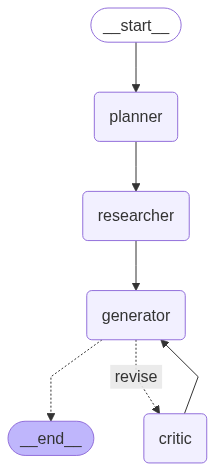

In [ ]:
graph

In [ ]:
thread = {
    "configurable": {"thread_id": "1"}
}

final_article = graph.invoke({
    'user_prompt': 'Write an article about the best tourist attractions in Cluj-Napoca, Romania.',
    'max_revisions': 2,
    'revision_number': 1
}, thread)

final_article

2025-07-04 13:18:50.607 | INFO     | __main__:plan_node:5 - PLANNER: Generating article outline...
2025-07-04 13:19:03.170 | INFO     | __main__:plan_node:11 - PLANNER: Article outline generated: **Article Outline: Exploring the Best Tourist Attractions in Cluj-Napoca, Romania**

**I. Introduction**
   - Brief overview of Cluj-Napoca: a vibrant city in Transylvania known for its rich history, cultural diversity, and youthful energy.
   - Importance of Cluj-Napoca as a tourist destination in Romania.
   - Mention of unique blend of historical and modern attractions.

**II. Historical and Cultural Landmarks**
   A. **St. Michael’s Church**
      - Description: Gothic architecture, history, and significance.
      - Notable features: The impressive altar and the bell tower.
   B. **Banffy Palace**
      - Overview: Home to the National Museum of Art.
      - Highlights: Art collections and architectural beauty.
   C. **The Tailors’ Tower**
      - Historical significance: One of the few r

{'user_prompt': 'Write an article about the best tourist attractions in Cluj-Napoca, Romania.',
 'article_plan': "**Article Outline: Exploring the Best Tourist Attractions in Cluj-Napoca, Romania**\n\n**I. Introduction**\n   - Brief overview of Cluj-Napoca: a vibrant city in Transylvania known for its rich history, cultural diversity, and youthful energy.\n   - Importance of Cluj-Napoca as a tourist destination in Romania.\n   - Mention of unique blend of historical and modern attractions.\n\n**II. Historical and Cultural Landmarks**\n   A. **St. Michael’s Church**\n      - Description: Gothic architecture, history, and significance.\n      - Notable features: The impressive altar and the bell tower.\n   B. **Banffy Palace**\n      - Overview: Home to the National Museum of Art.\n      - Highlights: Art collections and architectural beauty.\n   C. **The Tailors’ Tower**\n      - Historical significance: One of the few remaining medieval towers.\n      - Current use: A viewpoint and sma

#### 3.3.3. Honorable Mentions

<div style="width: 80%; text-align: justify">

Some other frameworks that you can try (not exhaustive by any means, feel free to search for more):
- Pydantic AI
- Smolagents
- AutoGen
- LlamaIndex
- Vertex AI

</div>

# 4. Assignment

<div style="width: 80%; text-align: justify">

<b>Objective</b>

Using the plant classifier models from your previous assignment, design a pipeline that passes your plant labels to a "Plant Care" data card generator agent.

1. Use the prompt engineering techniques presented in this lesson to build up a prompt template (e.g. "You are a world-class botanist...").
2. Using Pydantic, build up a structured output for your "Plant Care" data card response - e.g. fields like "latin_name", "outdoors" (True/False), "lighting_conditions".
3. Build up an agent using a library of your choosing (e.g. Langchain).
4. (Optional) Give your agent access to tools, like web search.
5. Set up your complete pipeline:
    - The input is a plant picture (e.g. from the Plant Data test split), which goes into your plant classification model (from lesson 9, e.g. VGG);
    - The class label predicted by the plant classification model (e.g. aloe vera) gets passed to your agent.
    - Your agent generates a Plant Care data card for your plant type, which is your final output.
</div>

<b>Deliverable</b>
- Your notebook containing the PlantCareCard Pydantic class, the prompt template, and the pipeline.
- Some example outputs (e.g. pictures of aloe vera, and their generated care cards).

# 5. Further Reading

- <b>LLMs</b>

    - <b>[3D visualization of an LLM, with a walkthrough](https://bbycroft.net/llm)</b> - Really cool interactive visualization that lets you see how tokens move through transformer layers. Great for building intuition about what's happening inside these models.

    - <b>[Andrej Karpathy (OpenAI cofounder) on Youtube - LLM Deep Dives](https://www.youtube.com/@AndrejKarpathy/videos)</b> - Karpathy explains things clearly and his "Let's build GPT" series is excellent for understanding the fundamentals. Good mix of theory and implementation.

    - <b>[Reverse Engineering Claude 3.5 Haiku, by Anthropic](https://transformer-circuits.pub/2025/attribution-graphs/biology.html)</b> - Recent research on interpretability that shows how we can understand what modern LLMs are doing internally. Technical but interesting if you want to see the latest approaches.

    - Official Blogs for <b>[Meta](https://ai.meta.com/blog/)</b>, <b>[OpenAI](https://openai.com/news/)</b>, <b>[Anthropic](https://www.anthropic.com/news?ref=monica-blog)</b>, <b>[Google](https://blog.google/products/gemini/)</b> - Best sources for staying current with new model releases and technical details from the companies building these systems.

    - <b>[How transformers work - DataCamp](https://www.datacamp.com/tutorial/how-transformers-work)</b> - Solid tutorial that covers transformers systematically with practical examples. Good for structured learning.

    - <b>[The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)</b> - Classic resource with excellent visual explanations of the transformer architecture. Still one of the clearest explanations available.

    - <b>[Cheat Sheet: Mastering Temperature and Top_p in ChatGPT API](https://community.openai.com/t/cheat-sheet-mastering-temperature-and-top-p-in-chatgpt-api/172683/1)</b> - A useful guide for using these two parameters.

    - <b> [METR](https://epoch.ai/benchmarks/metr-time-horizons) </b>

- <b>Prompt Engineering</b>

    - <b>[Prompt Engineering Guide](https://www.promptingguide.ai/)</b> - The most popular prompt engineer guide, with a vast collection of techniques / research findings.

    - <b>[Anthropic - Claude Prompting Best Practices](https://docs.anthropic.com/en/docs/build-with-claude/prompt-engineering/claude-4-best-practices)</b>

    - <b>[OpenAI Prompt Engineering Cookbook](https://cookbook.openai.com/examples/gpt4-1_prompting_guide)</b>

- <b>AI Agents</b>

    - <b>[Awesome LLM Agents - GitHub](https://github.com/kaushikb11/awesome-llm-agents)</b> - A curated list of awesome LLM agents frameworks.

    - <b>[AI_Agents subreddit](https://www.reddit.com/r/AI_Agents/)</b> - A place for discussion around the use of AI Agents and related tools.